# Jupyter notebook sample

In [1]:
import pandas as pd

In [1]:
import pandas as pd
import glob


path1 = "./BED/train/*.csv"
path2 = "./BED/test/*.csv"
path3 = "./BED/val/*.csv"
df_list1 = [pd.read_csv(file) for file in glob.glob(path1)]
df_list2 = [pd.read_csv(file) for file in glob.glob(path2)]
df_list3 = [pd.read_csv(file) for file in glob.glob(path3)]
df_train = pd.concat(df_list1, ignore_index=True)
df_test = pd.concat(df_list2, ignore_index=True)
df_val = pd.concat(df_list3, ignore_index=True)

In [2]:
df_train

,timestamp,throttle,pitch,roll,yaw,battery_current,altitude,latitude,longitude
0,287.216931,0.0,9.770000,3.500000,306.820000,0.005412,828.56,0.021003,0.711312
1,287.220277,0.0,9.770000,3.500000,306.820000,0.005412,828.56,0.021003,0.711312
2,287.220332,0.0,9.770000,3.500014,306.820029,0.005412,828.56,0.021003,0.711312
3,287.256927,0.0,9.770000,3.509659,306.839317,0.005412,828.56,0.021003,0.711312
4,287.258222,0.0,9.770000,3.510000,306.840000,0.005412,828.56,0.021003,0.711312
...,...,...,...,...,...,...,...,...,...
1659409,1789.553118,0.0,-14.726117,-57.354628,48.922104,0.005773,826.59,0.021174,0.711244
1659410,1789.554380,0.0,-14.740000,-57.350000,48.920000,0.005771,826.59,0.021174,0.711244
1659411,1789.554487,0.0,-14.740000,-57.350000,48.920000,0.005771,826.59,0.021174,0.711244
1659412,1789.573672,0.0,-14.740000,-57.350000,48.920000,0.005741,826.59,0.021174,0.711244


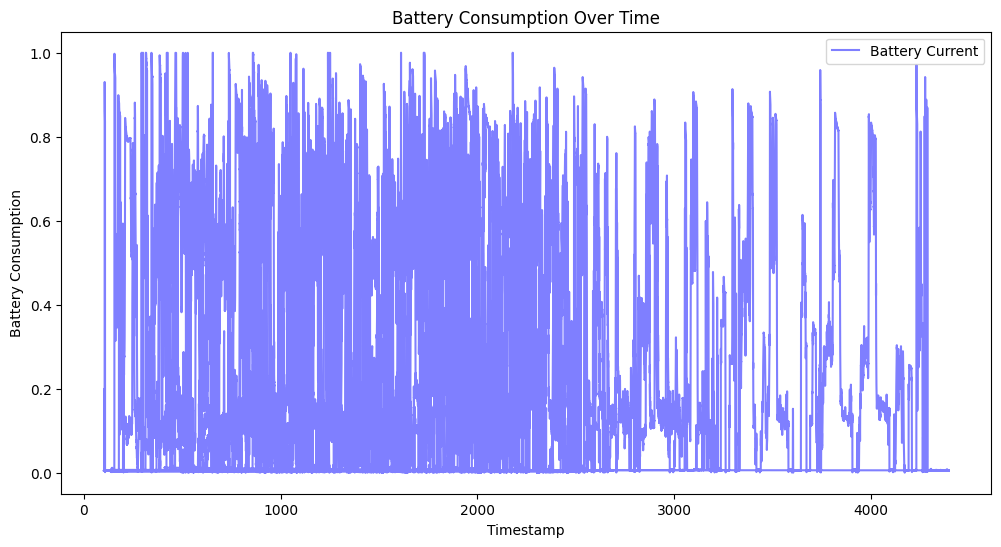

In [12]:
import matplotlib.pyplot as plt

# Plot battery consumption over time
plt.figure(figsize=(12, 6))
plt.plot(df_train["timestamp"], df_train["battery_current"], alpha=0.5, label="Battery Current", color="blue")
plt.xlabel("Timestamp")
plt.ylabel("Battery Consumption")
plt.title("Battery Consumption Over Time")
plt.legend()
plt.show()


In [13]:
import numpy as np

# Convert latitude & longitude to radians for distance calculation
df_train["lat_rad"] = np.radians(df_train["latitude"])
df_train["lon_rad"] = np.radians(df_train["longitude"])

# Earth's radius in meters
R = 6371000

# Compute time differences (to avoid division by zero issues)
df_train["time_diff"] = df_train["timestamp"].diff().fillna(1)

# Compute differences in latitude and longitude
df_train["dlat"] = df_train["lat_rad"].diff()
df_train["dlon"] = df_train["lon_rad"].diff()

# Compute haversine distance
a = np.sin(df_train["dlat"] / 2) ** 2 + np.cos(df_train["lat_rad"]) * np.cos(df_train["lat_rad"].shift()) * np.sin(df_train["dlon"] / 2) ** 2
c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
df_train["distance"] = R * c

# Compute velocity (distance / time)
df_train["velocity"] = df_train["distance"] / df_train["time_diff"]

# Compute acceleration (velocity change / time)
df_train["acceleration"] = df_train["velocity"].diff() / df_train["time_diff"]

# Convert latitude & longitude to radians for distance calculation
df_test["lat_rad"] = np.radians(df_test["latitude"])
df_test["lon_rad"] = np.radians(df_test["longitude"])

# Earth's radius in meters
R = 6371000

# Compute time differences (to avoid division by zero issues)
df_test["time_diff"] = df_test["timestamp"].diff().fillna(1)

# Compute differences in latitude and longitude
df_test["dlat"] = df_test["lat_rad"].diff()
df_test["dlon"] = df_test["lon_rad"].diff()

# Compute haversine distance
a = np.sin(df_test["dlat"] / 2) ** 2 + np.cos(df_test["lat_rad"]) * np.cos(df_test["lat_rad"].shift()) * np.sin(df_test["dlon"] / 2) ** 2
c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
df_test["distance"] = R * c

# Compute velocity (distance / time)
df_test["velocity"] = df_test["distance"] / df_test["time_diff"]

# Compute acceleration (velocity change / time)
df_test["acceleration"] = df_test["velocity"].diff() / df_test["time_diff"]


In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

features = ["throttle", "pitch", "roll", "yaw", "altitude", "velocity", "acceleration"]
target = "battery_current"

X_train, X_test, y_train, y_test = df_train[features], df_test[features], df_train[target], df_test[target]

model = RandomForestRegressor(n_estimators=10, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

(mae, rmse, r2)


(0.03874999384833873, np.float64(0.07050476853661305), 0.9263457217160576)